# 库导入

In [217]:
#  库导入
import numpy as np # 数值数学计算库
from scipy.integrate import quad # 积分计算库
from scipy import interpolate
from scipy import stats

import matplotlib.pyplot as plt # 绘图库
from matplotlib.ticker import FuncFormatter # 图表格式化库
from matplotlib.ticker import FormatStrFormatter

from typing import Tuple # 类型提示库
import pandas as pd # 使用pandas读取信息

from gapp import dgp # GP拟合方法库

from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import astropy.units as u
from astropy.cosmology import z_at_value



# 全局量设置

In [218]:
# 定义全局常量
np.random.seed(202506012)
# 光速
c_light=const.c.to(u.km/u.s).value  # 定义天文学中的光速
c_mpc_yr=const.c.to(u.Mpc/u.yr) # 将光速转化为Mpc/year 的情况

# 万有引力常数
Msun = const.M_sun
constG = 4.3009e-3

constc=const.c.to(u.Mpc/u.s).value # 转换换单位为 Mpc³ / (Msun·s²)，方便天体物理和宇宙学单位下使用
 
#ACDM标准宇宙学模型=cosmo内储存了一些常量+cosmo可以计算很多宇宙学（依据其所储存的常量）量
cosmo=FlatLambdaCDM(H0=67.64,Om0=0.3087)

In [219]:
def bar(i,n): 
    i=i+1
    print('\r['+'#'*int(40*i/n)+' '*(40-int(40*i/n))+']',end='')

# 用于计算的理论函数区（计算器）

In [220]:
# 计算ACDM模型下的红移与光度距离关系
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_ACDM(H0:float=67.64, Omega_M:float=0.3087, z=None, c:float=299792.458):
        """
        计算ACDM模型下的光度距离随红移的关系
        参数:
            H0       : 哈勃常数, km/s/Mpc
            Omega_M  : 物质密度参数
            n_points : 红移点数
            c        : 光速, km/s
        返回:
            z_vals  : 红移数组, numpy.ndarray
            dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
        """
        # 定义光度距离函数
        def d_L_em(z):
            def integrand(zp):
                return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
            integral, _ = quad(integrand, 0, z)
            return (1 + z) * (c / H0) * integral

        # 向量化函数
        d_L_em_vec = np.vectorize(d_L_em)

        # 红移数组
        z_vals = np.array(z)  # 确保 z 是 numpy 数组
        dL_vals = d_L_em_vec(z_vals)
        
        ACDM_theory_data = np.column_stack((z_vals, dL_vals))
        return ACDM_theory_data 

In [221]:
# 计算RT模型下的红移与光度距离关系
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_RT(Xi:float=1.67, n:float=1.94, z=None, c:float=299792.458):
    data = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


# 用于画图的理论函数区

In [222]:
# 计算ACDM模型下的红移与光度距离关系（平均红移点）
# 输入：(ACDM模型参数 H0, Ωm, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_ACDM(H0:float=67.64, Omega_M:float=0.3087, z_max:float=5, n_points:int=200, c:float=299792.458):
    """
    计算ACDM模型下的光度距离随红移的关系
    参数:
        H0       : 哈勃常数, km/s/Mpc
        Omega_M  : 物质密度参数
        z_max    : 红移最大值
        n_points : 红移点数
        c        : 光速, km/s
    返回:
        z_vals  : 红移数组, numpy.ndarray
        dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
    """
    # 定义光度距离函数
    def d_L_em(z):
        def integrand(zp):
            return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
        integral, _ = quad(integrand, 0, z)
        return (1 + z) * (c / H0) * integral

    # 向量化函数
    d_L_em_vec = np.vectorize(d_L_em)

    # 红移数组
    z_vals = np.linspace(0, z_max, n_points)
    dL_vals = d_L_em_vec(z_vals)
    
    ACDM_theory_data = np.column_stack((z_vals, dL_vals))
    return ACDM_theory_data 


In [223]:
# 计算RT模型下的红移与光度距离关系
# 输入：(RT模型参数 Xi, n, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_RT(Xi:float=1.67, n:float=1.94,z_max:float=5, n_points:int=200, c:float=299792.458):
    data = GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=z_max, n_points=n_points, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


# "实验"数据处理

In [224]:
#  根据参数生成此高斯函数对应的 (x,y) 数据点 这里一共是400个点
# 输入：(均值，方差) -> 输出：对应高斯函数的点(x数组[]，y数组[]) NumPy 数组
# def gaussian(mu: float, sigma2: float) -> Tuple[np.ndarray, np.ndarray]:
#     sigma = np.sqrt(sigma2)
#     x = np.linspace(mu - 10*sigma, mu + 10*sigma, 4000) # 在中值和方差定义的范围内生成等距x值,共400个点
#     y = (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(- (x - mu)**2 / (2 * sigma2))
#     return x, y

In [225]:
# 根据高斯分布随机取点 从理论d_L值到实验d_L值
# 输入：(均值，方差，采样点数) -> 输出：采样点数组sample[]  NumPy 数组
def sample_from_gaussian(mu: float, sigma2: float, n_samples: int = 1) -> np.ndarray:
    if mu == 0 and sigma2 == 0:
        return np.zeros(n_samples)
    # x, y = gaussian(mu, sigma2)
    # y_prob = y / y.sum()  # 将高斯函数值归一化为概率[这里是离散取点]，这里的y_prob也是一个数组
    # samples = np.random.choice(x, size=n_samples, p=y_prob)  # 按概率抽样
    samples = np.random.normal(loc=mu, scale=sigma2, size=n_samples)
    return samples

In [226]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组

In [227]:
# 读取CSV文件，生成随机样本，并返回处理后的的数据数组 实验dL值和z值组合为数组
# 输入：二维数组[][3] -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def gaussianrandom_to_newnumpy(data:np.ndarray) -> np.ndarray:
    samples_list = []

    # 忽略第一列 z值保留
    mu_values = data[:, 1]      # 第二列    
    sigma2_values = data[:, 2]    # 第三列 标准差变为方差   
    for mu, sigma2 in zip(mu_values, sigma2_values):
        sample = sample_from_gaussian(mu, sigma2,1)
        samples_list.append(sample[0])  # sample 是数组，取第0个元素
    samples_array = np.array(samples_list)

    new_data = np.column_stack((data[:, 0], samples_array, data[:, 2]))
    return new_data

In [228]:
# 根据文件数据读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def ACDM_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z_values, c=299792.458)
    mu_values = data2[:,1]      # 第二列    
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [229]:
# 读取根据文件数据，读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def GT_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_RT(Xi=1.67, n=1.94, z=z_values, c=299792.458)
    mu_values = data2[:,1]     # 第二列
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [230]:
# 使用GaPP方法处理二维数组
# 输入：(二维数组data_array[][3], 以及模型参数) -> 输出：GaPP处理后的二维数组GaPP_data[][]
def gapp_solve(data:np.ndarray, xmin=0.0, xmax=10.0, nstar=200, initheta=[2.0,2.0]):
    """
    对输入数据 X,Y,Sigma 执行 Gaussian Process 重构
    
    返回：
    - Xstar: 重构函数对应横坐标
    - rec: 重构函数
    - drec: 一阶导数
    - d2rec: 二阶导数
    - d3rec: 三阶导数
    """
    X = data[:,0]
    Y = data[:,1]
    Sigma = data[:,2]

    # initialization of the Gaussian Process
    g = dgp.DGaussianProcess(X, Y, Sigma, cXstar=(xmin, xmax, nstar))

    # training of the hyperparameters and reconstruction of the function
    (rec, theta) = g.gp(theta=initheta)
    # 注意rec是重构函数的二维数组 横坐标[:,0] , 纵坐标[:,1] , 误差值[:,2]

    # reconstruction of the first, second and third derivatives.
    # theta is fixed to the previously determined value.
    (drec, theta) = g.dgp(thetatrain='False')
    (d2rec, theta) = g.d2gp()
    (d3rec, theta) = g.d3gp()
    
    # 用字典返回多个值
    result = {
        "X": X,
        "Y": Y,
        "Sigma": Sigma,
        "rec": rec,
        "drec": drec,
        "d2rec": d2rec,
        "d3rec": d3rec,
        "theta": theta
    }
    return result

# Montecarlo处理

In [259]:
# 根据一个高斯分布的均值和误差进行蒙特卡洛撒点
# 主要输入： 一个均值和标准差 -> 输出： 采样得到的5000000个点
def montecarlo_gaussian(mu,sigma,n_sample=500000,random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # 生成高斯分布的随机样本
    samples = np.random.normal(loc=mu, scale=sigma, size=n_sample)
    
    return samples

In [260]:
# 输入：一维数组 -> 输出 ：一对 均值和标准差
def anaylize_array(sample):
    sample = np.asarray(sample)
    # 忽略 NaN
    sample = sample[~np.isnan(sample)]
    # mean = np.mean(sample)
    # std = np.std(sample, ddof=1)  # ddof=1 表示无偏估计
    p50 = np.percentile(sample, 50)
    p2o5 = np.percentile(sample, 2.5)
    p97o5 = np.percentile(sample, 97.5)
    p16 = np.percentile(sample, 16)
    p84 = np.percentile(sample, 84)
    return p50, p2o5, p97o5, p16, p84

In [261]:
# 根据一组 两队的均值和误差进行撒点后 计算比值
# 主要输入： 一对均值和标准差 -> 输出： 一组500000个的比值
def montecarlo_ratio(meanA,stdA,meanB,stdB,n_sample):
    samplesA = montecarlo_gaussian(meanA,stdA,n_sample)
    samplesB = montecarlo_gaussian(meanB,stdB,n_sample)
    ratio = samplesA / np.where(samplesB == 0, np.nan, samplesB) # 避免除以0

    return ratio

In [262]:
# 输入 :2 个 二维数组[][3] -> 输出 ：1 个 二维数组[][3]
def montecarlo_ratio_group(arrayA,arrayB,n_sample=500000):
    ratio_results = []
    print("montecarlo_ratio_group")
    for i in range(len(arrayA)):
        z = arrayA[i, 0]                      # 当前行的 z 值
        meanA, stdA = arrayA[i, 1], arrayA[i, 2]
        meanB, stdB = arrayB[i, 1], arrayB[i, 2]
        p50, p2o5, p97o5, p16, p84 = anaylize_array(montecarlo_ratio(meanA,stdA,meanB,stdB,n_sample))
        ratio_results.append([z, p50, p2o5, p97o5, p16, p84])
        bar(i,len(arrayA))

    # ratio_results.append([z, mean, std])
    return np.array(ratio_results)

In [263]:
# 输出一组500000个的
def montecarlo_gravity(meanA,stdA,n_sample,mu=1):
    samplesA = montecarlo_gaussian(meanA,stdA,n_sample)
    Geff = (samplesA**2 )

    return Geff

In [264]:
# 输入 :1 个 二维数组[][3] -> 输出 ：1 个 二维数组[][3]
def montecarlo_gravity_group(arrayA,n_sample=500000):
    gravity_results = []
    print("\n montecarlo_gravity_group")
    for i in range(len(arrayA)):
        z = arrayA[i, 0]                      # 当前行的 z 值
        meanA, stdA = arrayA[i, 1], arrayA[i, 2]
        p50, p2o5, p97o5, p16, p84 = anaylize_array(montecarlo_gravity(meanA,stdA,n_sample))
        gravity_results.append([z, p50, p2o5, p97o5, p16, p84])
        bar(i,len(arrayA))

    # gravity_results.append([z, mean, std])
    return np.array(gravity_results)

# 画图区

In [265]:
# 绘制二维数组对应的理论曲线图（绘制曲线时使用）
# 输入：(二维数组data_array[..][2], 图例标签，) -> 输出：无（一个待打印的图）
def plot_line(data:np.ndarray, label:str,linecolor:str='red'):
    X = data[:,0]
    Y = data[:,1]
    plt.plot(X, Y, label=label, color=linecolor, linewidth=1.2)

In [266]:
# 绘制二维数组带error bar的散点图
# 输入：(二维数组data_array[..][3], 图例标签，点线样式，误差条颜色) -> 输出：无（一个待打印的图）
def plot_spot_with_error(data: np.ndarray, label: str = "Data", fmt: str='_', color:str='red'):
    """
    绘制带误差条的折线图（不创建新图、不调用 plt.show()，方便多次叠加）
    参数:
    - data: 二维 NumPy 数组, 每行 [x, y, error]
    - label: 图例标签
    - fmt: 点线样式
    - ecolor: 误差条颜色
    """
    x = data[:, 0]
    y = data[:, 1]
    yerr = data[:, 2]

    plt.errorbar(x, y, yerr=yerr, fmt=fmt, ecolor=color, elinewidth=0.5 ,color=color,label=label)

In [239]:
# 绘制GaPP处理后的二维数据的图（输入数据字典）
# 输入：数据字典 -> 输出：无（一个待打印的图）
def plot_gapp(result_dict: dict, color ="red",Label: str = "Reconstruction from GP"):
    X = result_dict["X"]
    Y = result_dict["Y"]
    Sigma = result_dict["Sigma"]
    rec = result_dict["rec"]
    drec = result_dict["drec"]
    d2rec = result_dict["d2rec"]
    d3rec = result_dict["d3rec"]
    
    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)
    # plt.errorbar(X, Y, Sigma, color='red', fmt='_')
    

In [240]:
# 绘制GaPP处理后的二维数据的图
# 输入：二维数组[][3] -> 输出：无（一个待打印的图）
def plot_gapp_further(rec, color ="red" ,Label: str = "Reconstruction from GP"):

    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)

    

In [267]:
# 绘制Montecarlo处理后的二维数据的图（输入二维数组） z,p50, p2o5, p97o5, p16, p84
# 输入：二维数组[][4](红移值、均值、95%分位值、68%分炜值) -> 输出：无（一个待打印的图）
def plot_montecarlo(rec, color ="red" ,Label: str = "Reconstruction from GP"):
    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 2] , rec[:, 3] , facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 4] , rec[:, 5] , facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)

In [242]:
# 控制生成figure的结构
def plot_show(
        xlimDOWN:float=0,xlimUP:float=0.12, 
        ylimDOWN=None, ylimUP=None,
        xlabel:str="Redshift z", ylabel:str="", 
        title:str="", zoom:float=1000.0,
):
    # plt.figure(figsize=(8,5))
    plt.xlim(xlimDOWN, xlimUP)
    
    # 设置纵轴上下限
    if ylimDOWN is not None and ylimUP is not None:
        plt.ylim(ylimDOWN, ylimUP)
    elif ylimDOWN is not None:
        plt.ylim(bottom=ylimDOWN)
    elif ylimUP is not None:
        plt.ylim(top=ylimUP)
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.3f}'))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show() 

# 一阶重构

In [243]:
dataACDM_GW = gapp_solve(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[0.2,0.001])

  NIT   NF   F                       GTG
    0    1  2.493244182789785E+03   7.45786810E+02
tnc: fscale = 0.0346047
    1   11  2.489415656618271E+03   3.91250968E+03
    2   13  2.489065918194945E+03   9.19494706E+03
tnc: stepmx = 1000
    3   18  6.040440100876906E+02   2.75061255E+07
tnc: fscale = 0.000190475
    4   21  5.121781235548090E+02   1.50204236E+06
    5   23  5.084827351218224E+02   4.01212345E+04
tnc: fscale = 0.00492274
    6   25  5.083942311993421E+02   2.68162667E+03
    7   28  1.310088257797235E+02   1.59055462E+04
    8   31  8.850731977713895E+01   3.46381600E+01
tnc: fscale = 0.169737
    9   42  8.840404397640356E+01   2.11372673E+00
   10   44  8.840306691317480E+01   8.59295775E-02
   11   51  8.766862916063334E+01   4.64234767E+02
   12   54  8.509435726848446E+01   1.12865876E+03
   13   56  8.367592682065631E+01   7.54006055E+00
   14   61  8.353290979824428E+01   8.42396163E+01
   15   63  8.332861153982881E+01   1.52234233E+00
   16   65  8.330530248407


Optimized hyperparameters:
theta = [6.82164578e+02 2.16787691e-01]


In [244]:
dataGR_EM = gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[2.0,0.01])

  NIT   NF   F                       GTG
    0    1  3.206709509716279E+04   5.51365737E+09
tnc: fscale = 1.33274e-05
    1    5  2.940506057086692E+04   1.79506338E+08
    2    8  2.454781714285784E+04   2.28060483E+09
    3   10  7.039634194333385E+03   1.93972435E+08
    4   14  4.298382482040575E+03   1.52695812E+08
    5   17  3.792224595290264E+03   3.42031747E+07
    6   19  2.883640910459675E+03   4.47696981E+03
tnc: fscale = 0.00722641
    7   21  2.880932279835675E+03   8.45132795E+04
tnc: stepmx = 1000
    8   24  2.216615547075384E+03   3.71999057E+04
    9   28  1.939603665158233E+03   3.22564163E+06
   10   31  1.853063992794283E+03   2.40362049E+04
   11   34  1.771652855258649E+03   3.55805012E+05
   12   37  1.746995342853927E+03   7.32923733E+02
   13   40  1.738104994014625E+03   2.13727202E+03
   14   43  1.733536067717672E+03   1.98004157E+01
tnc: fscale = 0.222505
   15   45  1.733366827391270E+03   8.48532101E-02
   16   47  1.733365974348604E+03   7.16048064E-06


Optimized hyperparameters:
theta = [3.41133827e+03 9.44021965e-01]


tnc: |fn-fn-1] = 3.60281e-09 -> convergence
   22   61  1.732112136515928E+03   1.75261566E-07
tnc: Converged (|f_n-f_(n-1)| ~= 0)


In [245]:
dataGR_GW = gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[0.2,0.01])

  NIT   NF   F                       GTG
    0    1  2.984157581628665E+03   1.47698297E+04
tnc: fscale = 0.007984
    1    7  2.982570928956986E+03   3.35634758E+03
    2   10  2.934834894793693E+03   3.87202783E+05
tnc: stepmx = 1000
    3   12  2.735822397524687E+03   5.63043955E+05
    4   14  2.079258937677858E+03   6.86428776E+05
    5   16  3.528639365302712E+02   1.26003087E+05
    6   20  9.265644039324542E+01   4.12853693E+03
    7   25  7.967920832785268E+01   1.15098809E+00
tnc: fscale = 0.922873
    8   27  7.967807208344750E+01   5.41141893E-05
tnc: fscale = 126.534
    9   29  7.967807198366754E+01   3.34617252E-05
   10   32  7.920001894319398E+01   7.41529098E+00
tnc: fscale = 0.363592
   11   34  7.915750099229129E+01   1.86408189E-02
   12   36  7.915740063358817E+01   1.75483372E-07
tnc: fscale = 2148.29
tnc: |fn-fn-1] = 2.83793e-09 -> convergence
   13   38  7.915740063075023E+01   2.76436760E-07
tnc: Converged (|f_n-f_(n-1)| ~= 0)



Optimized hyperparameters:
theta = [1.33591343e+03 3.23044047e-01]


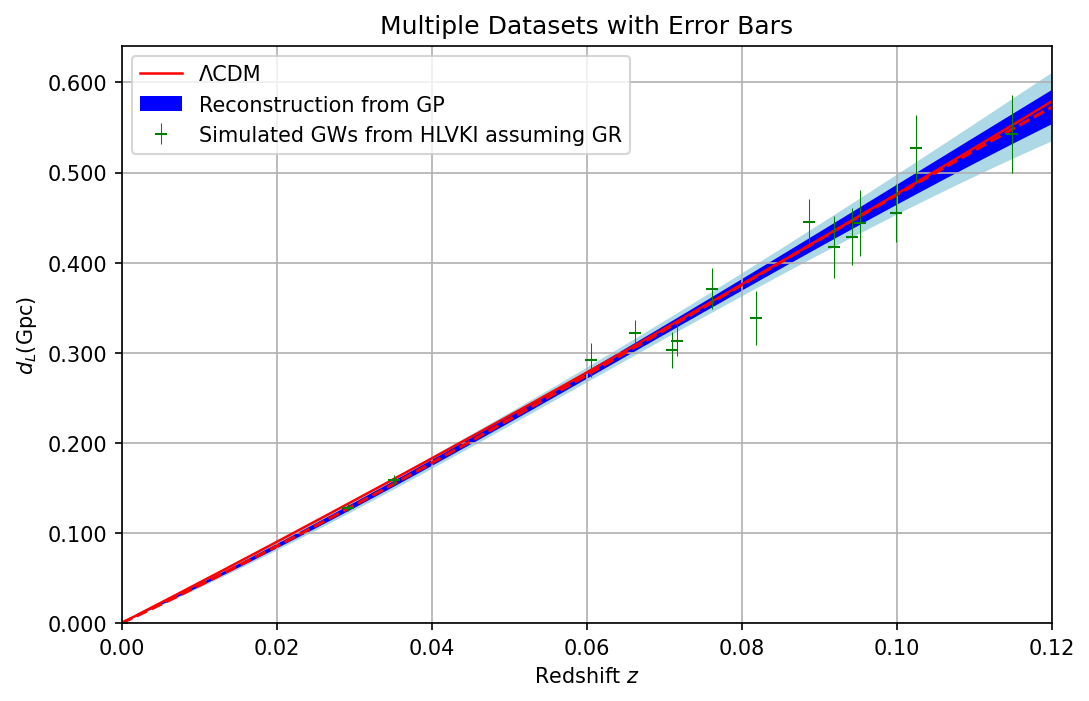

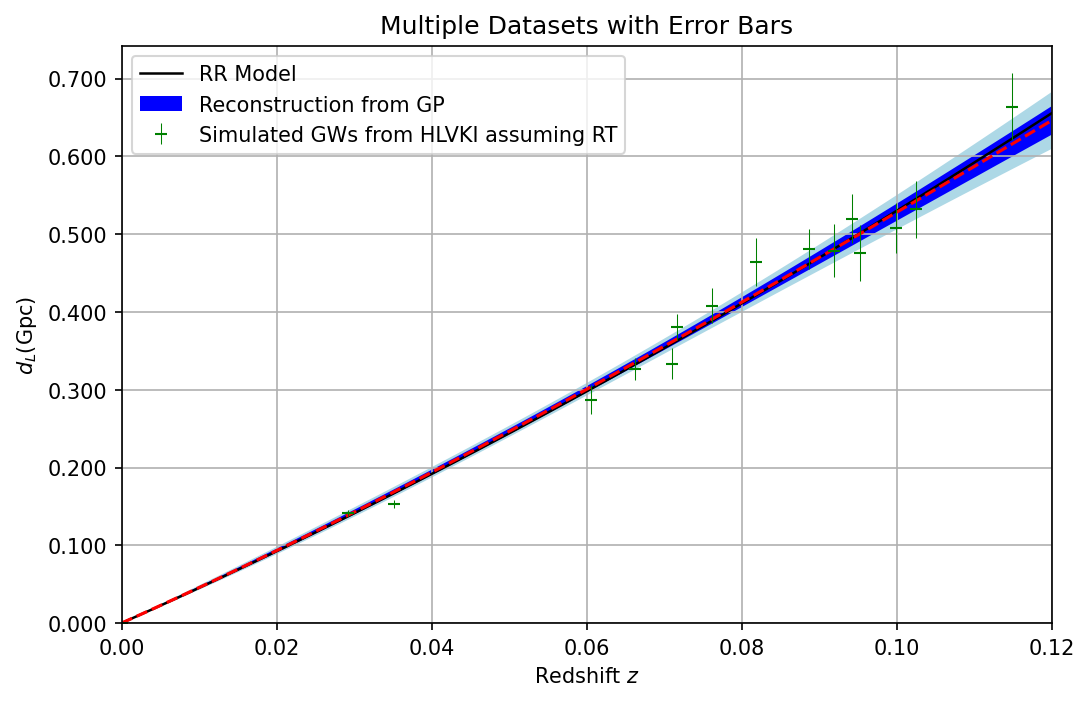

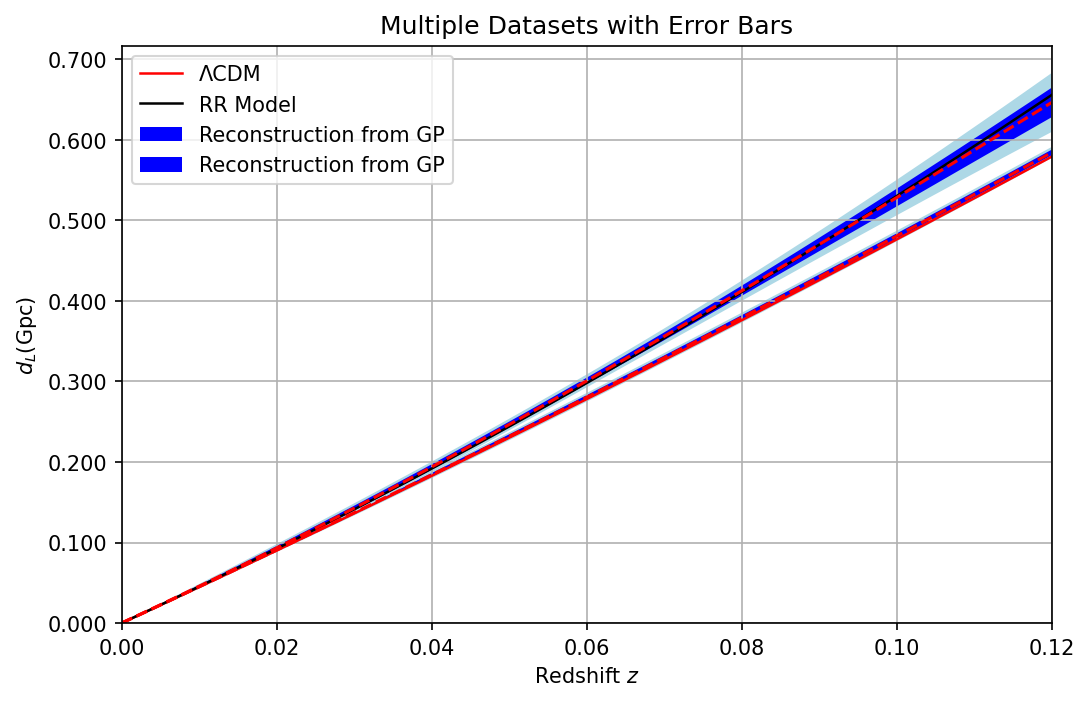

In [246]:
plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.12, n_points=200), label='ΛCDM', linecolor='red')
plot_gapp(dataACDM_GW, Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(GW_forplot_RT(Xi=1.67, n=1.94, z_max=0.12, n_points=200), label='RR Model', linecolor='black')
# plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[0.2,0.01]), Label='Reconstruction from GP')
plot_gapp(dataGR_GW, Label='Reconstruction from GP')
plot_spot_with_error(GT_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming RT', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

# plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
# plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.5, n_points=200), label='ΛCDM', linecolor='red')
# plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.5, nstar=1000, initheta=[2.0,0.01]), Label='Reconstruction from GP')
# plot_spot_with_error(ACDM_csv_to_newnumpy('Data/outputEM.csv'), label='Simulated EMs from HLVKI assuming GR', fmt='_', color='green')
# plot_show(xlimDOWN=0,xlimUP=0.5,ylimDOWN=0, xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.12, n_points=200), label='ΛCDM', linecolor='red')
plot_line(GW_forplot_RT(Xi=1.67, n=1.94, z_max=0.12, n_points=200), label='RR Model', linecolor='black')
plot_gapp(dataGR_EM, color ="red",Label='Reconstruction from GP')
# plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[2.0,0.01]),color="black", Label='GW Reconstruction from GP')
plot_gapp(dataGR_GW, Label='Reconstruction from GP')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)


# 二阶重构

## 计算理论比值

In [268]:
def Dz_GR(z_max,n_point):
    x = np.linspace(0,z_max,n_point)
    y = np.full_like(x, 1.0)
    Dz = np.column_stack((x,y))
    return Dz
    

In [269]:
# 输入：最大值和需要拟合点的个数（平均取点） -> 输出一个二维数组
def Dz_RT(z_max,n_point):
    x = np.linspace(0,z_max,n_point) 
    d_EM = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=x, c=c_light)
    d_GW = GW_calculate_RT(Xi=1.67, n=1.94, z=x, c=c_light)

    # 处理 0/0 的情况
    y = np.zeros_like(x)
    y[1:] = d_GW[1:,1] / d_EM[1:,1]
    y[0] = 1.0  # 理论上在z=0时应相等

    Dz = np.column_stack((x,y))
    return Dz

# Dz = Dz_RT(1.2,100)
# print(Dz[:10])

## 计算实验重构比值

In [273]:
def Dz_gapp_GR():
    # GWz =gapp_solve (GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[1000.0,0.01])
    GWz = dataGR_GW
    # EMz = gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[200.0,0.01])
    EMz = dataGR_EM

    recGW = GWz["rec"]
    recEM = EMz["rec"]

    # x1, y1, sigma1 = recGW[:,0], recGW[:,1], recGW[:,2]
    # x2, y2, sigma2 = recEM[:,0], recEM[:,1], recEM[:,2]

    # Dz = y1 / y2 
    
    # Sigma = np.sqrt( (sigma1/y2)**2 + (y1*sigma2/(y2)**2)**2 )

    
    # data = np.column_stack((x1,Dz,Sigma))
    # print(y2)
    # print(y2)
    
    # data[0, 1] = 1.0
    # data[0, 2] = 0.0
    # print(Sigma)
    data = montecarlo_ratio_group(recGW,recEM,500000)
    return data
Dz_gapp_GR()


montecarlo_ratio_group
[########################################]

array([[ 0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
       [ 1.20120120e-04,  1.00202756e+00,  9.23478964e-01,
         1.08252456e+00,  9.61871618e-01,  1.04259739e+00],
       [ 2.40240240e-04,  1.00204874e+00,  9.24125198e-01,
         1.08270605e+00,  9.62153348e-01,  1.04266043e+00],
       ...,
       [ 1.19759760e-01,  1.10620120e+00,  1.04379601e+00,
         1.16876797e+00,  1.07451011e+00,  1.13803167e+00],
       [ 1.19879880e-01,  1.10627897e+00,  1.04377788e+00,
         1.16901903e+00,  1.07451418e+00,  1.13799160e+00],
       [ 1.20000000e-01,  1.10630727e+00,  1.04379154e+00,
         1.16918462e+00,  1.07466476e+00,  1.13824772e+00]],
      shape=(1000, 6))

montecarlo_ratio_group
[########################################]

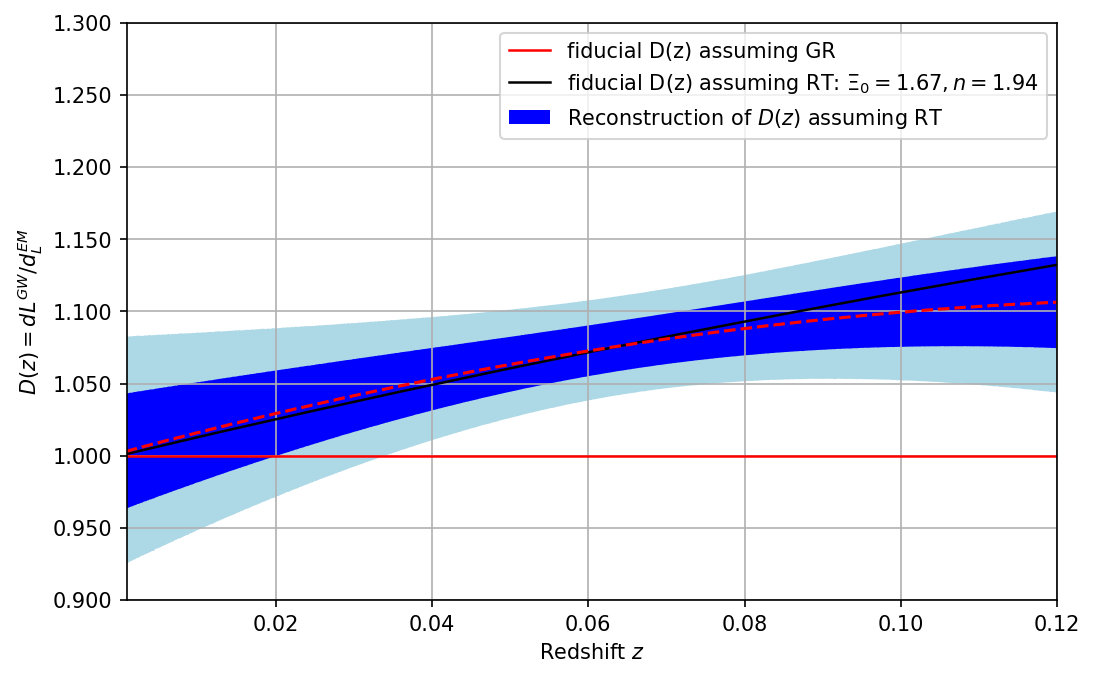

In [272]:
plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(Dz_GR(1.2,100), label='fiducial D(z) assuming GR', linecolor='red')
plot_line(Dz_RT(1.2,100), label='fiducial D(z) assuming RT: $\Xi_0 =1.67, n=1.94$', linecolor='black')
plot_montecarlo(Dz_gapp_GR(), Label='Reconstruction of $D(z)$ assuming RT')
# plot_gapp(gapp_solve(Dz_gapp_GR(), xmin=0, xmax=0.12, nstar=200, initheta=[20.0,0.04]), Label='Reconstruction from GP')
plot_show(xlimDOWN=0.001,xlimUP=0.12,ylimDOWN=0.9, ylimUP=1.30, xlabel="Redshift $z$", ylabel="$D(z)= dL^{GW} / d_L^{EM}$",zoom=1)

# 三阶重构

## 牛顿引力常数的重构

In [251]:
def Gravity_RT(z_max,npoints):
    data = Dz_RT(z_max,npoints)
    y = (data[:,1] ** 2) 
    x = data[:,0]
    Gravity = np.column_stack((x,y))
    return Gravity

In [252]:
def Gravity_gapp_RT(n_sample=500000):
    data = Dz_gapp_GR()
    Gravity = montecarlo_gravity_group(data,n_sample)
    return Gravity

# Gravity_gapp_RT()

montecarlo_ratio_group
[########################################]
 montecarlo_gravity_group
[########################################]

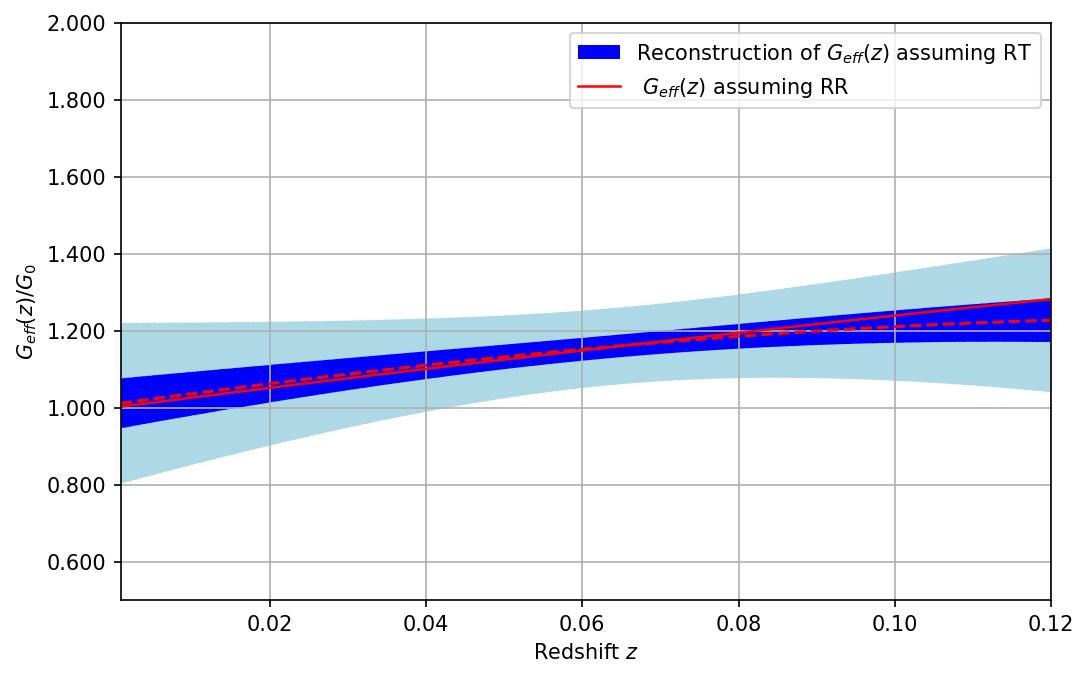

In [258]:
plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_montecarlo(Gravity_gapp_RT(), Label='Reconstruction of $G_{eff}(z)$ assuming RT')
# plot_gapp(gapp_solve(Dz_gapp_GR(), xmin=0, xmax=0.12, nstar=200, initheta=[20.0,0.04]), Label='Reconstruction from GP')
plot_line(Gravity_RT(1.2,100), label=' $G_{eff}(z)$ assuming RR', linecolor='red')
plot_show(xlimDOWN=0.001,xlimUP=0.12,ylimDOWN=0.5,ylimUP=2.0, xlabel="Redshift $z$", ylabel="$G_{eff}(z)/G_0$",zoom=1)
